# Rollout & analisi
Fa giocare un modello addestrato contro la CPU su più istanze Dolphin in parallelo e salva, per ogni decisione: **observation, Q-values, azione, attivazioni**, più reward/stock/percent.

- `run_rollouts(...)` → lancia le partite e salva i `.npz` (+ `meta.json`).
- `load_rollout(dir)` → ricarica tutto per l'analisi.

I checkpoint in `weights/` sono `full_obs` (obs=30) + `a_b` (act=27).

In [1]:
from smash_rl.rollout import run_rollouts, load_rollout

In [ ]:
replay_dir = "replays/rollout"

In [2]:
# --- ricarica i record ---
r = load_rollout("rollouts/test")   # load_activations=False per un caricamento leggero
print(r)
print("episodi:", len(r), "| win_rate:", r.win_rate)
print("obs feature names:", r.obs_feature_names)
print("action labels:", r.action_labels)

Rollout(rollouts/test, episodes=6, win_rate=0.00)
episodi: 6 | win_rate: 0.0
obs feature names: ['x ag', 'y ag', 'vx ag', 'vy ag', 'vx kb ag', 'vy kb ag', '% ag', 'stock ag', 'facing ag', 'x av', 'y av', 'vx av', 'vy av', 'vx kb av', 'vy kb av', '% av', 'stock av', 'facing av', 'dx rel', 'dy rel', 'hitstun ag', 'hitstun av', 'salti ag', 'salti av', 'terra ag', 'terra av', 'fuori ag', 'fuori av', 'invuln ag', 'invuln av']
action labels: ['neutro', 'neutro + A', 'neutro + B', 'su', 'su + A', 'su + B', 'giu', 'giu + A', 'giu + B', 'sx', 'sx + A', 'sx + B', 'dx', 'dx + A', 'dx + B', 'su-sx', 'su-sx + A', 'su-sx + B', 'su-dx', 'su-dx + A', 'su-dx + B', 'giu-sx', 'giu-sx + A', 'giu-sx + B', 'giu-dx', 'giu-dx + A', 'giu-dx + B']


In [6]:
# --- un singolo episodio ---
e = r[0]
print(e)
print("obs       ", e.obs.shape)          # (T, 30)
print("q_values  ", e.q_values.shape)     # (T, 27)
print("action    ", e.action.shape)       # (T,)
print("activations", [a.shape for a in e.activations])  # per layer nascosto
print("reward/stock/percent disponibili: e.reward, e.P1_stocks, e.P2_stocks, e.P1_percent, e.P2_percent")

Episode(worker_0/000.npz, steps=1970, lost)
obs        (1970, 30)
q_values   (1970, 27)
action     (1970,)
activations [(1970, 256), (1970, 256)]
reward/stock/percent disponibili: e.reward, e.P1_stocks, e.P2_stocks, e.P1_percent, e.P2_percent


In [4]:
# --- tutti gli episodi concatenati (array numpy) ---
c = r.concat()
print({k: (v.shape if hasattr(v, "shape") else [a.shape for a in v]) for k, v in c.items()})
# c["episode_id"] dice a quale episodio appartiene ogni passo.

{'episode_id': (10671,), 'obs': (10671, 30), 'q_values': (10671, 27), 'action': (10671,), 'stick': (10671, 2), 'button': (10671,), 'reward': (10671,), 'P1_stocks': (10671,), 'P2_stocks': (10671,), 'P1_percent': (10671,), 'P2_percent': (10671,), 'activations': [(10671, 256), (10671, 256)]}


giu-dx + A     2905
giu-sx + A     2357
giu-sx         1366
giu            726
sx + A         446
dx             328
neutro + B     294
giu + B        258
su-sx + A      210
su             184
su-dx + B      167
dx + B         153
sx             129
su-sx + B      129
dx + A         118
su + A         114
su-dx          108
sx + B         105
giu-sx + B     103
su + B         101
neutro + A     99
giu-dx + B     97
giu + A        95
su-dx + A      29
giu-dx         24
su-sx          18
neutro         8


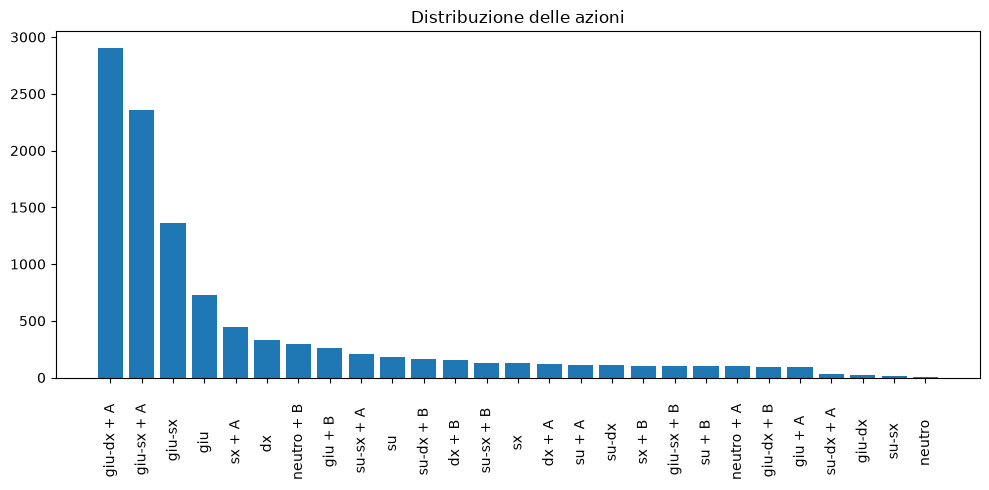

In [5]:
# --- esempio: distribuzione delle azioni ---
import numpy as np
import matplotlib.pyplot as plt
acts, counts = np.unique(c["action"], return_counts=True)
labels = r.action_labels
for a, n in sorted(zip(acts, counts), key=lambda t: -t[1]):
    print(f"{labels[a]:<14} {n}")

plt.figure(figsize=(10, 5))

sort_idx = np.argsort(counts)[::-1]

plt.bar([f"{labels[a]:<14}" for a in acts[sort_idx]], counts[sort_idx])
plt.xticks(rotation=90)
plt.title("Distribuzione delle azioni")
plt.tight_layout()
plt.show()